In [2]:
# ─────────────────────────────────────────────
# Notebook 02 - Exploratory Data Analysis (EDA)
# Goal: Understand patterns in hospital 
# uncompensated care costs before modeling
# ─────────────────────────────────────────────

# Standard libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create outputs folder if it doesn't exist
# This is where we'll save all our plots
os.makedirs('../outputs', exist_ok=True)

# Load the cleaned dataset we created in notebook 01
# Path goes one level up (../) from notebooks/ to reach data/
df = pd.read_csv('../data/cleaned_hospital_data.csv')

# Quick sanity check — should be (22745, 27)
print(df.shape)

(22745, 27)


/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


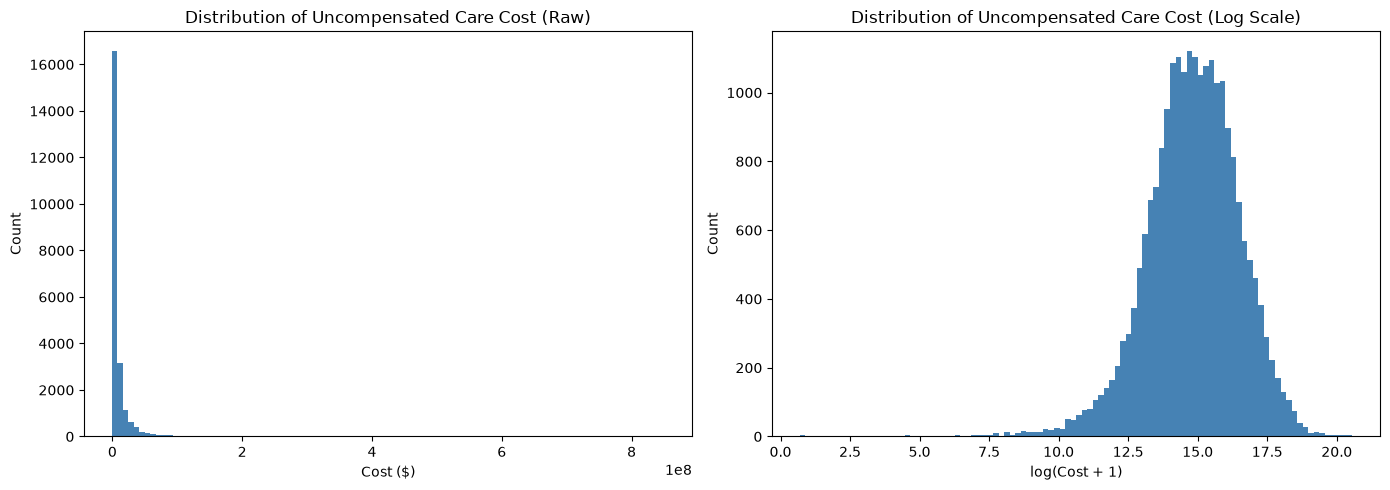

count    2.274500e+04
mean     8.912685e+06
std      2.355120e+07
min     -8.874550e+05
25%      1.004021e+06
50%      2.894337e+06
75%      8.353212e+06
max      8.504827e+08
Name: Cost of Uncompensated Care, dtype: float64

Median: $2,894,337
Mean:   $8,912,685
% of hospitals under $10M: 78.7%


In [3]:
# ─────────────────────────────────────────────
# Section 1 - Target Variable Distribution
# Goal: Understand the shape of our target 
# variable (Cost of Uncompensated Care)
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: raw values
# We expect this to be heavily right-skewed
# because a few large hospitals have very high costs
axes[0].hist(df['Cost of Uncompensated Care'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution of Uncompensated Care Cost (Raw)')
axes[0].set_xlabel('Cost ($)')
axes[0].set_ylabel('Count')

# Right plot: log-transformed values
# log1p = log(x + 1), handles zeros safely
# This should look more bell-shaped (normal)
# which is what ML models prefer
axes[1].hist(np.log1p(df['Cost of Uncompensated Care']), bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Distribution of Uncompensated Care Cost (Log Scale)')
axes[1].set_xlabel('log(Cost + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()

# Save plot to outputs folder for later use in README/portfolio
plt.savefig('../outputs/01_target_distribution.png', dpi=150)
plt.show()

# Summary statistics — median vs mean gap tells us how skewed the data is
print(df['Cost of Uncompensated Care'].describe())
print(f"\nMedian: ${df['Cost of Uncompensated Care'].median():,.0f}")
print(f"Mean:   ${df['Cost of Uncompensated Care'].mean():,.0f}")
print(f"% of hospitals under $10M: {(df['Cost of Uncompensated Care'] < 10_000_000).mean()*100:.1f}%")

State Code
GU    17306792.5
FL    12283227.5
NJ    10276054.0
DC     9278409.0
DE     9183688.5
MD     8629395.0
NC     8037355.0
SC     8007881.0
GA     7533958.0
VI     7370874.0
CT     5891556.5
TX     5636863.0
VA     5074285.0
MO     4917658.0
MA     4445668.0
CA     4241730.0
NY     4098602.0
NV     4033435.5
TN     3979394.5
AZ     3729661.0
Name: Cost of Uncompensated Care, dtype: float64


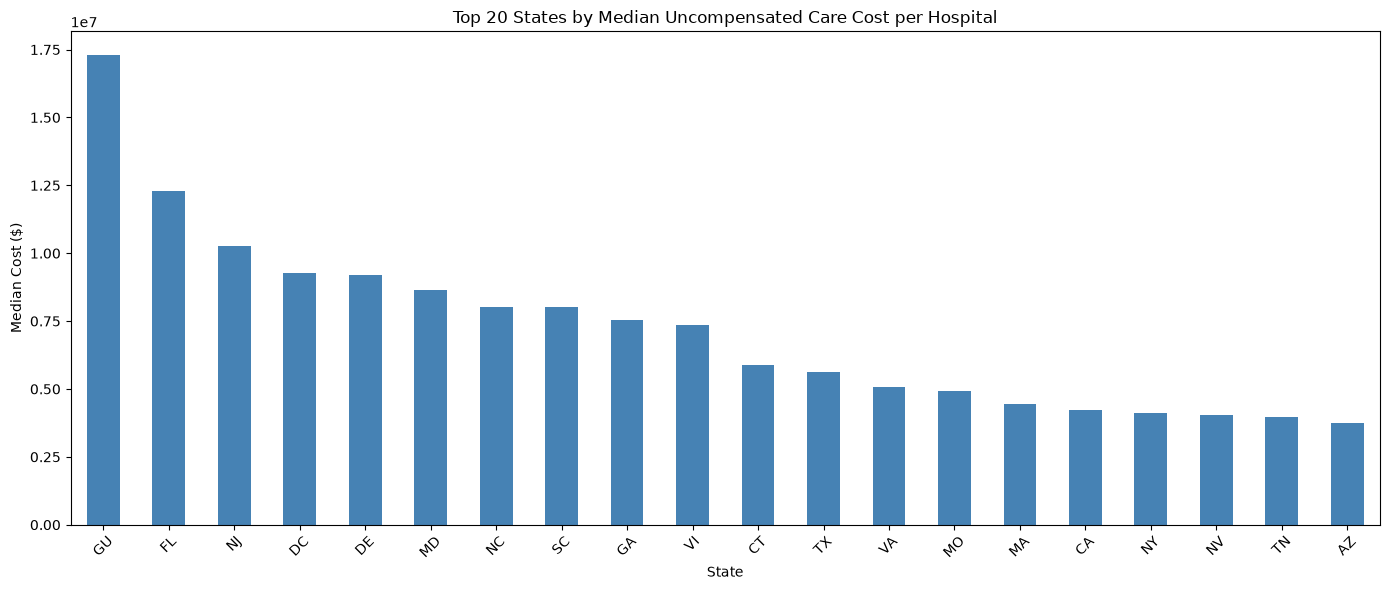

In [4]:
# ─────────────────────────────────────────────
# Section 2 - Geographic Patterns by State
# Goal: Find which states have the highest 
# uncompensated care burden per hospital
# We use MEDIAN not mean to avoid large 
# hospitals skewing the results
# ─────────────────────────────────────────────

# Calculate median uncompensated care per state
# and take the top 20 states
state_avg = (df.groupby('State Code')['Cost of Uncompensated Care']
               .median()
               .sort_values(ascending=False)
               .head(20))

print(state_avg)

plt.figure(figsize=(14, 6))
state_avg.plot(kind='bar', color='steelblue', edgecolor='none')
plt.title('Top 20 States by Median Uncompensated Care Cost per Hospital')
plt.xlabel('State')
plt.ylabel('Median Cost ($)')
plt.xticks(rotation=45)
plt.tight_layout()

# Save for portfolio/README
plt.savefig('../outputs/02_uncompensated_by_state.png', dpi=150)
plt.show()

Rural Versus Urban
R    1694988.0
U    5382958.5
Name: Cost of Uncompensated Care, dtype: float64


/home/codespace/.local/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


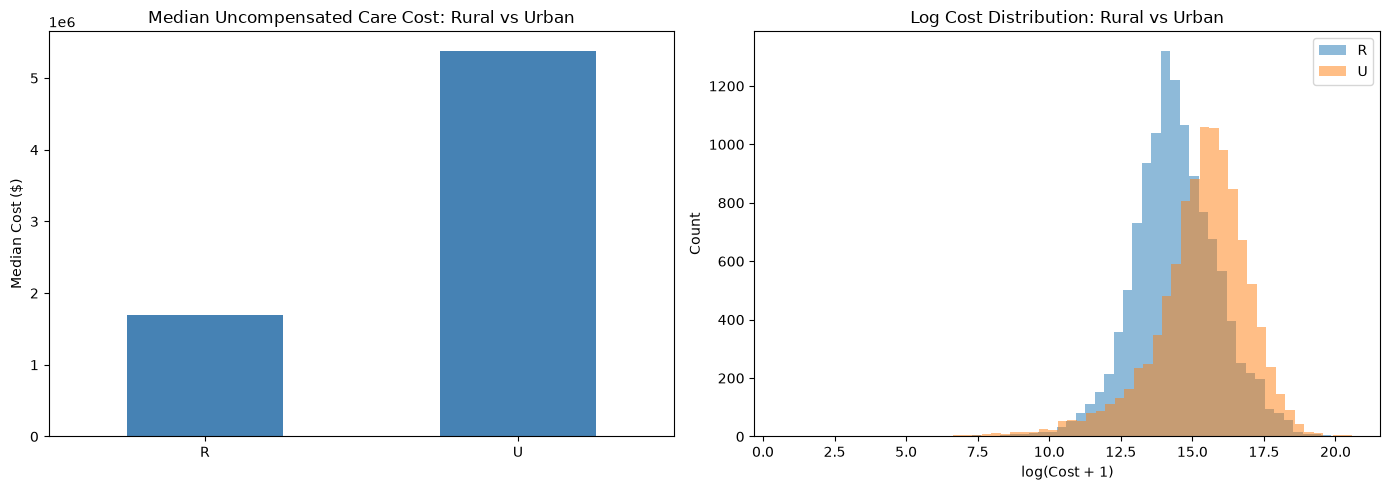

In [5]:
# ─────────────────────────────────────────────
# Section 3 - Rural vs Urban Comparison
# Goal: Compare uncompensated care burden 
# between rural and urban hospitals
# Important: raw dollars favor urban simply 
# because urban hospitals are bigger —
# we'll address this in feature engineering
# with a per-bed ratio
# ─────────────────────────────────────────────

# Print the median for each group first
rural_urban = df.groupby('Rural Versus Urban')['Cost of Uncompensated Care'].median()
print(rural_urban)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: median cost bar chart
# Shows raw dollar difference between rural and urban
rural_urban.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title('Median Uncompensated Care Cost: Rural vs Urban')
axes[0].set_ylabel('Median Cost ($)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Right: overlapping log distributions
# Shows the full shape of each group's distribution
# alpha=0.5 makes bars semi-transparent so both are visible
for label, group in df.groupby('Rural Versus Urban'):
    axes[1].hist(np.log1p(group['Cost of Uncompensated Care']),
                 bins=60, alpha=0.5, label=label, edgecolor='none')
axes[1].set_title('Log Cost Distribution: Rural vs Urban')
axes[1].set_xlabel('log(Cost + 1)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/03_rural_vs_urban.png', dpi=150)
plt.show()

   year     median          mean
0  2019  3013709.5  8.864846e+06
1  2020  2959567.0  8.629910e+06
2  2021  2731508.0  8.508906e+06
3  2022  2851038.0  8.990037e+06
4  2023  2936524.0  9.576986e+06


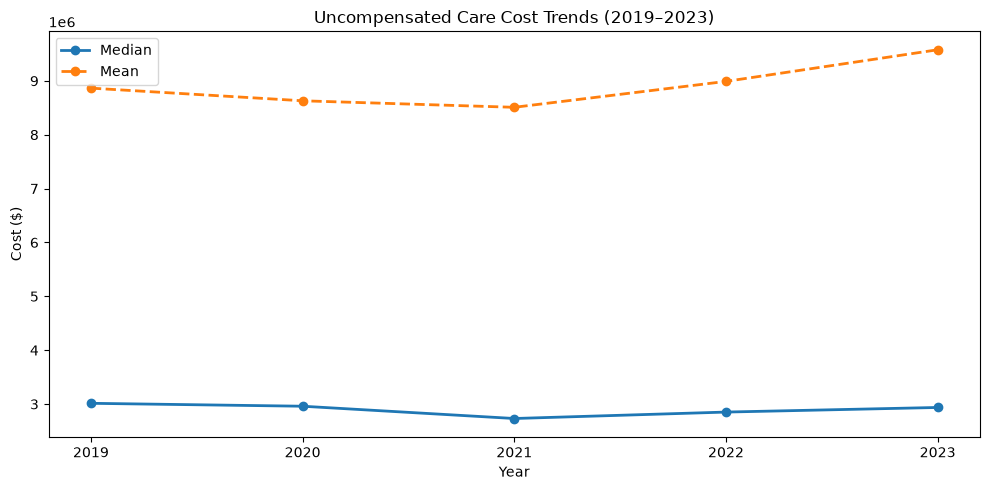

In [6]:
# ─────────────────────────────────────────────
# Section 4 - COVID Era Time Trends (2019-2023)
# Goal: See how uncompensated care changed 
# during and after COVID
# Key insight: costs DROPPED in 2020-2021
# not because things improved, but because:
# 1. Fewer patients came in (elective care cancelled)
# 2. Federal CARES Act relief funding covered costs
# Then costs SURGED post-2022 as relief dried up
# ─────────────────────────────────────────────

# Calculate both median and mean per year
# median = typical hospital, mean = pulled up by large hospitals
yearly = (df.groupby('year')['Cost of Uncompensated Care']
            .agg(['median', 'mean'])
            .reset_index())

print(yearly)

plt.figure(figsize=(10, 5))

# Plot both lines to show how large hospitals (mean)
# behaved differently from typical hospitals (median)
plt.plot(yearly['year'], yearly['median'], marker='o', 
         label='Median', linewidth=2)
plt.plot(yearly['year'], yearly['mean'], marker='o', 
         label='Mean', linewidth=2, linestyle='--')

plt.title('Uncompensated Care Cost Trends (2019–2023)')
plt.xlabel('Year')
plt.ylabel('Cost ($)')
plt.legend()
plt.xticks(yearly['year'])
plt.tight_layout()
plt.savefig('../outputs/04_yearly_trends.png', dpi=150)
plt.show()

   year     median          mean
0  2019  3013709.5  8.864846e+06
1  2020  2959567.0  8.629910e+06
2  2021  2731508.0  8.508906e+06
3  2022  2851038.0  8.990037e+06
4  2023  2936524.0  9.576986e+06


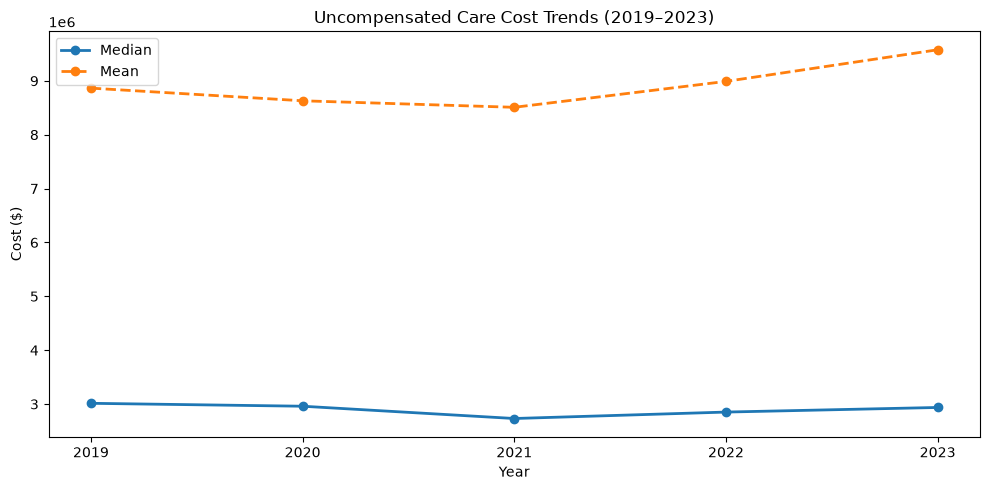

In [7]:
# Convert year to integer first
df['year'] = df['year'].astype(int)

# Now rerun the trend analysis
yearly = (df.groupby('year')['Cost of Uncompensated Care']
            .agg(['median', 'mean'])
            .reset_index())

print(yearly)

plt.figure(figsize=(10, 5))
plt.plot(yearly['year'], yearly['median'], marker='o', label='Median', linewidth=2)
plt.plot(yearly['year'], yearly['mean'], marker='o', label='Mean', linewidth=2, linestyle='--')
plt.title('Uncompensated Care Cost Trends (2019–2023)')
plt.xlabel('Year')
plt.ylabel('Cost ($)')
plt.legend()
plt.xticks(yearly['year'])
plt.tight_layout()
plt.savefig('../outputs/04_yearly_trends.png', dpi=150)
plt.show()

In [8]:
print(df['year'].unique())
print(df['year'].value_counts())

[2019 2020 2021 2022 2023]
year
2019    4638
2021    4557
2020    4529
2022    4515
2023    4506
Name: count, dtype: int64


Cost of Charity Care                            0.983440
Total Bad Debt Expense                          0.713545
Total Discharges (V + XVIII + XIX + Unknown)    0.571394
Total Days Title XIX                            0.559069
FTE - Employees on Payroll                      0.552913
Total Costs                                     0.538849
Total Patient Revenue                           0.492275
Net Patient Revenue                             0.480098
Total Days Title XVIII                          0.449191
Net Revenue from Medicaid                       0.370169
Total Assets                                    0.266371
Net Income                                      0.208205
Total Liabilities                               0.183272
Number of Beds                                  0.008590
dtype: float64


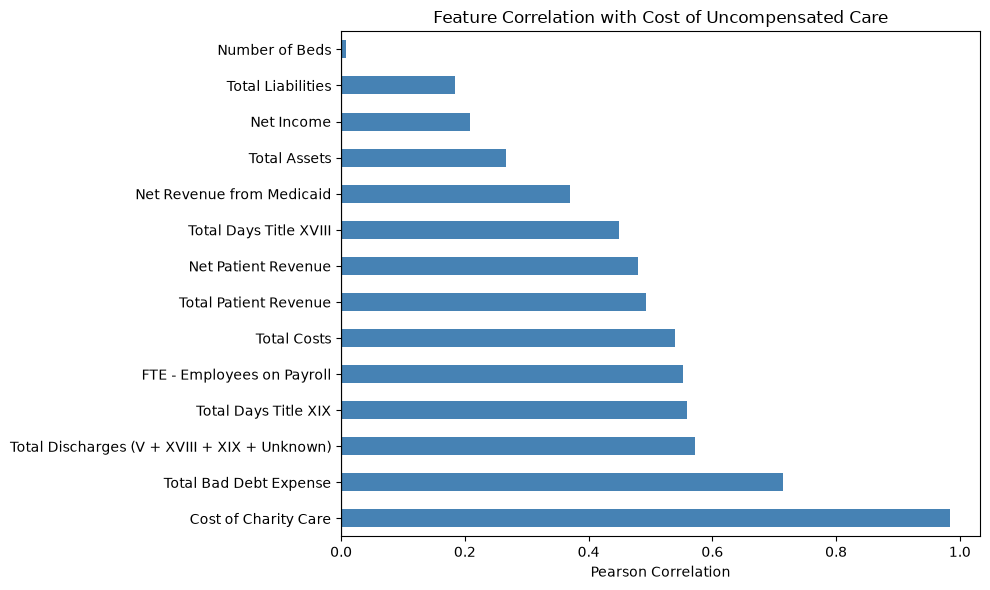

In [9]:
# ─────────────────────────────────────────────
# Section 5 - Feature Correlation Analysis
# Goal: Find which features correlate most 
# strongly with our target variable
# This directly informs which features to 
# include in the ML model
# Pearson correlation ranges from -1 to +1:
# +1 = perfect positive relationship
# -1 = perfect negative relationship
#  0 = no relationship
# ─────────────────────────────────────────────

numeric_cols = [
    'Number of Beds', 'FTE - Employees on Payroll',
    'Total Days Title XVIII', 'Total Days Title XIX',
    'Total Discharges (V + XVIII + XIX + Unknown)',
    'Cost of Charity Care', 'Total Bad Debt Expense',
    'Total Patient Revenue', 'Net Patient Revenue',
    'Net Income', 'Net Revenue from Medicaid',
    'Total Assets', 'Total Liabilities', 'Total Costs'
]

# Calculate correlation of each feature with our target
correlations = (df[numeric_cols]
                .corrwith(df['Cost of Uncompensated Care'])
                .sort_values(ascending=False))

print(correlations)

plt.figure(figsize=(10, 6))
correlations.plot(kind='barh', color='steelblue', edgecolor='none')
plt.title('Feature Correlation with Cost of Uncompensated Care')
plt.xlabel('Pearson Correlation')

# Reference line at 0
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/05_correlations.png', dpi=150)
plt.show()